# Credit Risk EDA — Commerce Data

## Business Context
We're building a **proxy credit risk model** for Bati Bank using transaction data from the Xente eCommerce platform. There is no direct "default" label — we'll engineer one from behavioral patterns (RFM).

This notebook covers:
1. Data overview & structure
2. Summary statistics
3. Numerical & categorical distributions
4. Correlation analysis
5. Missing values & outlier detection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="tab10")

df = pd.read_csv("../data/raw/alternate_data.csv", parse_dates=["TransactionStartTime"])
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [3]:
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nUnique customers: {df['CustomerId'].nunique()}")
print(f"Date range: {df['TransactionStartTime'].min()} → {df['TransactionStartTime'].max()}")

Shape: (95662, 16)

Data Types:
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object

Unique customers: 3742
Date range: 2018-11-15 02:18:49+00:00 → 2019-02-13 10:01:28+00:00


## Summary Statistics
Quick look at central tendency and spread of numerical columns.

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TransactionId,95662,95662,TransactionId_76871,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,256.0,256.0,256.0,256.0,256.0,0.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values found.")
else:
    print(missing)
    missing.plot(kind="bar", title="Missing Values per Column")
    plt.tight_layout(); plt.show()

No missing values found.


## Numerical Feature Distributions (Transaction Level)
Raw transaction amounts before any aggregation. `Amount` can be negative (refunds/credits back to customer). `Value` is always positive — the absolute amount.

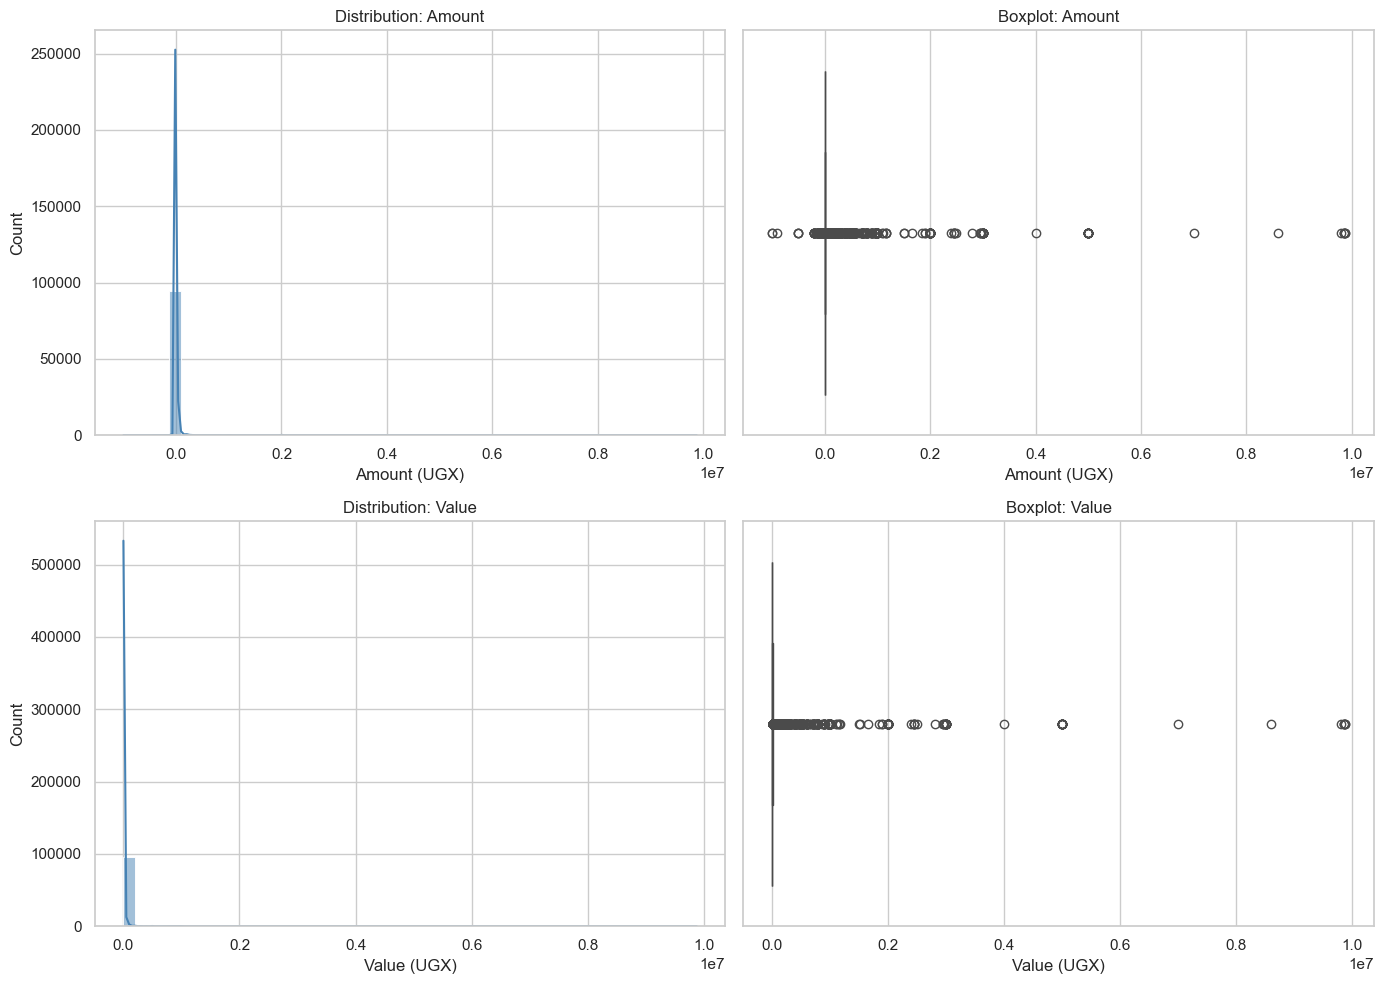

In [15]:
num_cols = ["Amount", "Value"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="steelblue", bins=50)
    axes[i, 0].set_title(f"Distribution: {col}")
    axes[i, 0].set_xlabel(f"{col} (UGX)")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"Boxplot: {col}")
    axes[i, 1].set_xlabel(f"{col} (UGX)")

plt.tight_layout()
plt.show()

## Categorical Feature Distributions
Top categories for `ProductCategory`, `ChannelId`, `ProviderId`, and `PricingStrategy`.

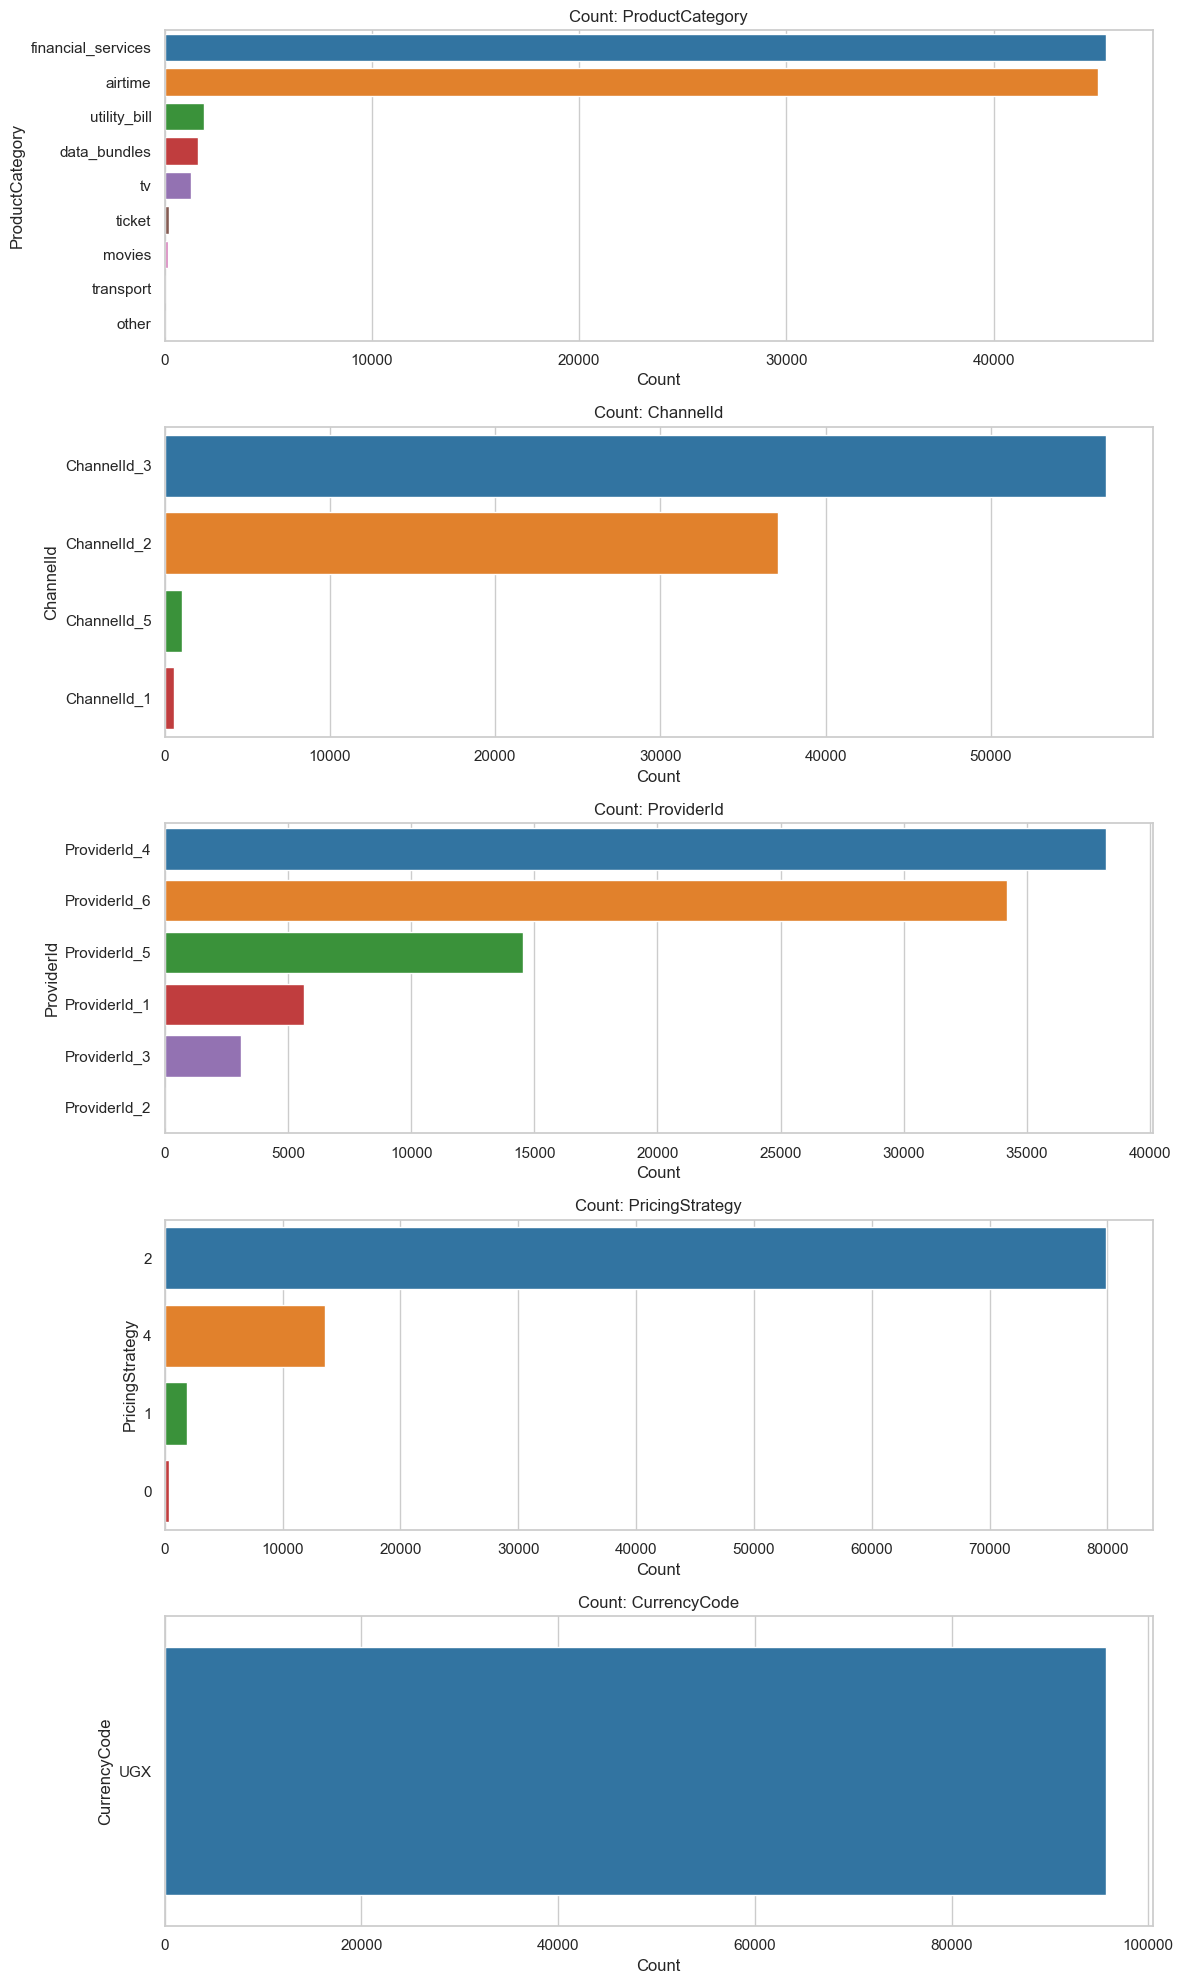

In [7]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "PricingStrategy", "CurrencyCode"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="tab10")
    axes[i].set_title(f"Count: {col}")
    axes[i].set_xlabel("Count")

plt.tight_layout(); plt.show()

## Transaction Volume Over Time
Are there any seasonal or temporal spikes in transaction activity?

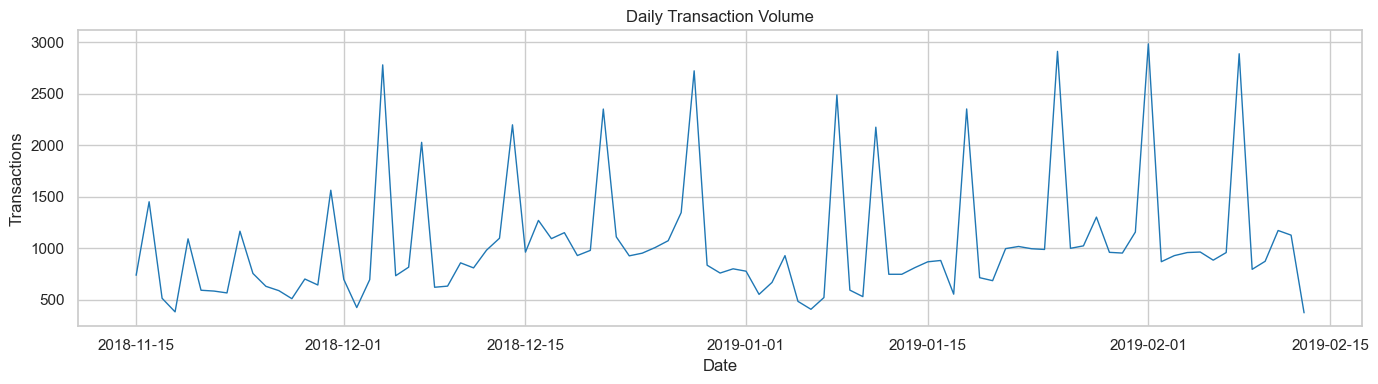

In [8]:
df["date"] = df["TransactionStartTime"].dt.date
daily = df.groupby("date")["TransactionId"].count().reset_index()
daily.columns = ["date", "count"]

plt.figure(figsize=(14, 4))
plt.plot(pd.to_datetime(daily["date"]), daily["count"], linewidth=1)
plt.title("Daily Transaction Volume")
plt.xlabel("Date"); plt.ylabel("Transactions")
plt.tight_layout(); plt.show()

## Transaction Hour & Day Patterns
When do customers transact most?

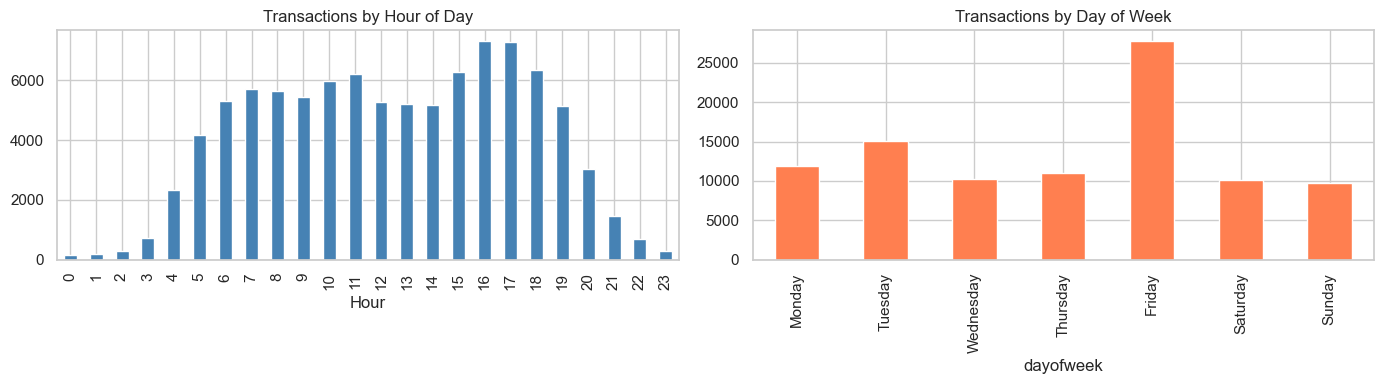

In [24]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["dayofweek"] = df["TransactionStartTime"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Transactions by Hour of Day")
axes[0].set_xlabel("Hour")

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["dayofweek"].value_counts().reindex(dow_order).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Transactions by Day of Week")

plt.tight_layout(); plt.show()

## Fraud Distribution
`FraudResult` is highly imbalanced — this is typical in fraud datasets and will inform how we treat class imbalance in modeling.

FraudResult
0    95469
1      193
Name: count, dtype: int64

Fraud rate: 0.20%


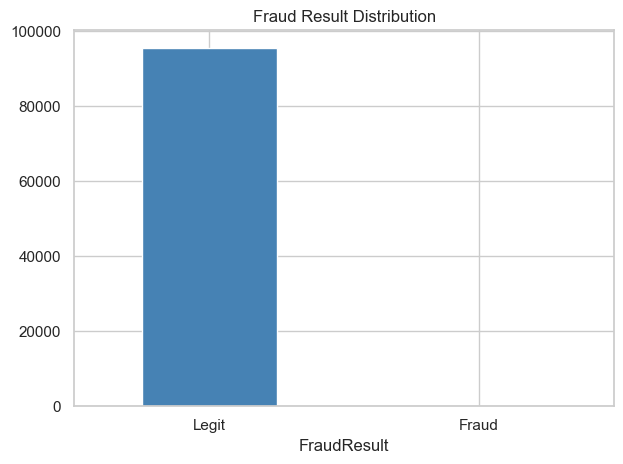

In [25]:
fraud_counts = df["FraudResult"].value_counts()
print(fraud_counts)
print(f"\nFraud rate: {fraud_counts[1] / len(df):.2%}")

fraud_counts.plot(kind="bar", title="Fraud Result Distribution", color=["steelblue","coral"])
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.tight_layout(); plt.show()

## Correlation Analysis
Computed on the RFM-aggregated customer-level data to see relationships between behavioral features.

In [26]:
import sys; sys.path.append("..")
from src.data_processing import compute_rfm

rfm = compute_rfm(df)
print(rfm.shape)
rfm.head()

2026-06-03 20:27:25,293 [INFO] Computing RFM with snapshot date: 2019-02-14 10:01:28+00:00
2026-06-03 20:27:27,229 [INFO] RFM aggregation complete: 3742 customers, 16 columns.


(3742, 16)


,CustomerId,recency_days,transaction_count,total_amount,avg_amount,std_amount,total_value,fraud_count,txn_hour_mean,txn_day_mean,ProductCategory,ChannelId,ProviderId,ProductId,CurrencyCode,PricingStrategy
0,CustomerId_1,84,1,-10000.0,-10000.000000,0.000000,10000,0,16.000000,21.000000,airtime,ChannelId_2,ProviderId_4,ProductId_10,UGX,4
1,CustomerId_10,84,1,-10000.0,-10000.000000,0.000000,10000,0,16.000000,21.000000,airtime,ChannelId_2,ProviderId_4,ProductId_3,UGX,4
2,CustomerId_1001,90,5,20000.0,4000.000000,6558.963333,30400,0,7.800000,16.000000,financial_services,ChannelId_3,ProviderId_4,ProductId_10,UGX,2
3,CustomerId_1002,26,11,4225.0,384.090909,560.498966,4775,0,13.454545,14.727273,financial_services,ChannelId_2,ProviderId_4,ProductId_6,UGX,2
4,CustomerId_1003,12,6,20000.0,3333.333333,6030.478146,32000,0,14.333333,1.000000,airtime,ChannelId_3,ProviderId_6,ProductId_10,UGX,2


In [27]:
from src.data_processing import build_risk_label

rfm = build_risk_label(rfm)
print(rfm["is_high_risk"].value_counts())
rfm.head()

2026-06-03 20:27:30,614 [INFO] Risk label assigned. High-risk cluster: 2 | is_high_risk=1: 1 / 3742


is_high_risk
0    3741
1       1
Name: count, dtype: int64


,CustomerId,recency_days,transaction_count,total_amount,avg_amount,std_amount,total_value,fraud_count,txn_hour_mean,txn_day_mean,ProductCategory,ChannelId,ProviderId,ProductId,CurrencyCode,PricingStrategy,is_high_risk
0,CustomerId_1,84,1,-10000.0,-10000.000000,0.000000,10000,0,16.000000,21.000000,airtime,ChannelId_2,ProviderId_4,ProductId_10,UGX,4,0
1,CustomerId_10,84,1,-10000.0,-10000.000000,0.000000,10000,0,16.000000,21.000000,airtime,ChannelId_2,ProviderId_4,ProductId_3,UGX,4,0
2,CustomerId_1001,90,5,20000.0,4000.000000,6558.963333,30400,0,7.800000,16.000000,financial_services,ChannelId_3,ProviderId_4,ProductId_10,UGX,2,0
3,CustomerId_1002,26,11,4225.0,384.090909,560.498966,4775,0,13.454545,14.727273,financial_services,ChannelId_2,ProviderId_4,ProductId_6,UGX,2,0
4,CustomerId_1003,12,6,20000.0,3333.333333,6030.478146,32000,0,14.333333,1.000000,airtime,ChannelId_3,ProviderId_6,ProductId_10,UGX,2,0


## Customer-Level Distributions by Risk Label
Now that we have `is_high_risk` from K-Means clustering, we can compare how high-risk vs low-risk customers differ across RFM features. This is the meaningful comparison — not raw transactions.

2026-06-03 20:33:11,691 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 20:33:11,697 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 20:33:11,795 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 20:33:11,802 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 20:33:11,900 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

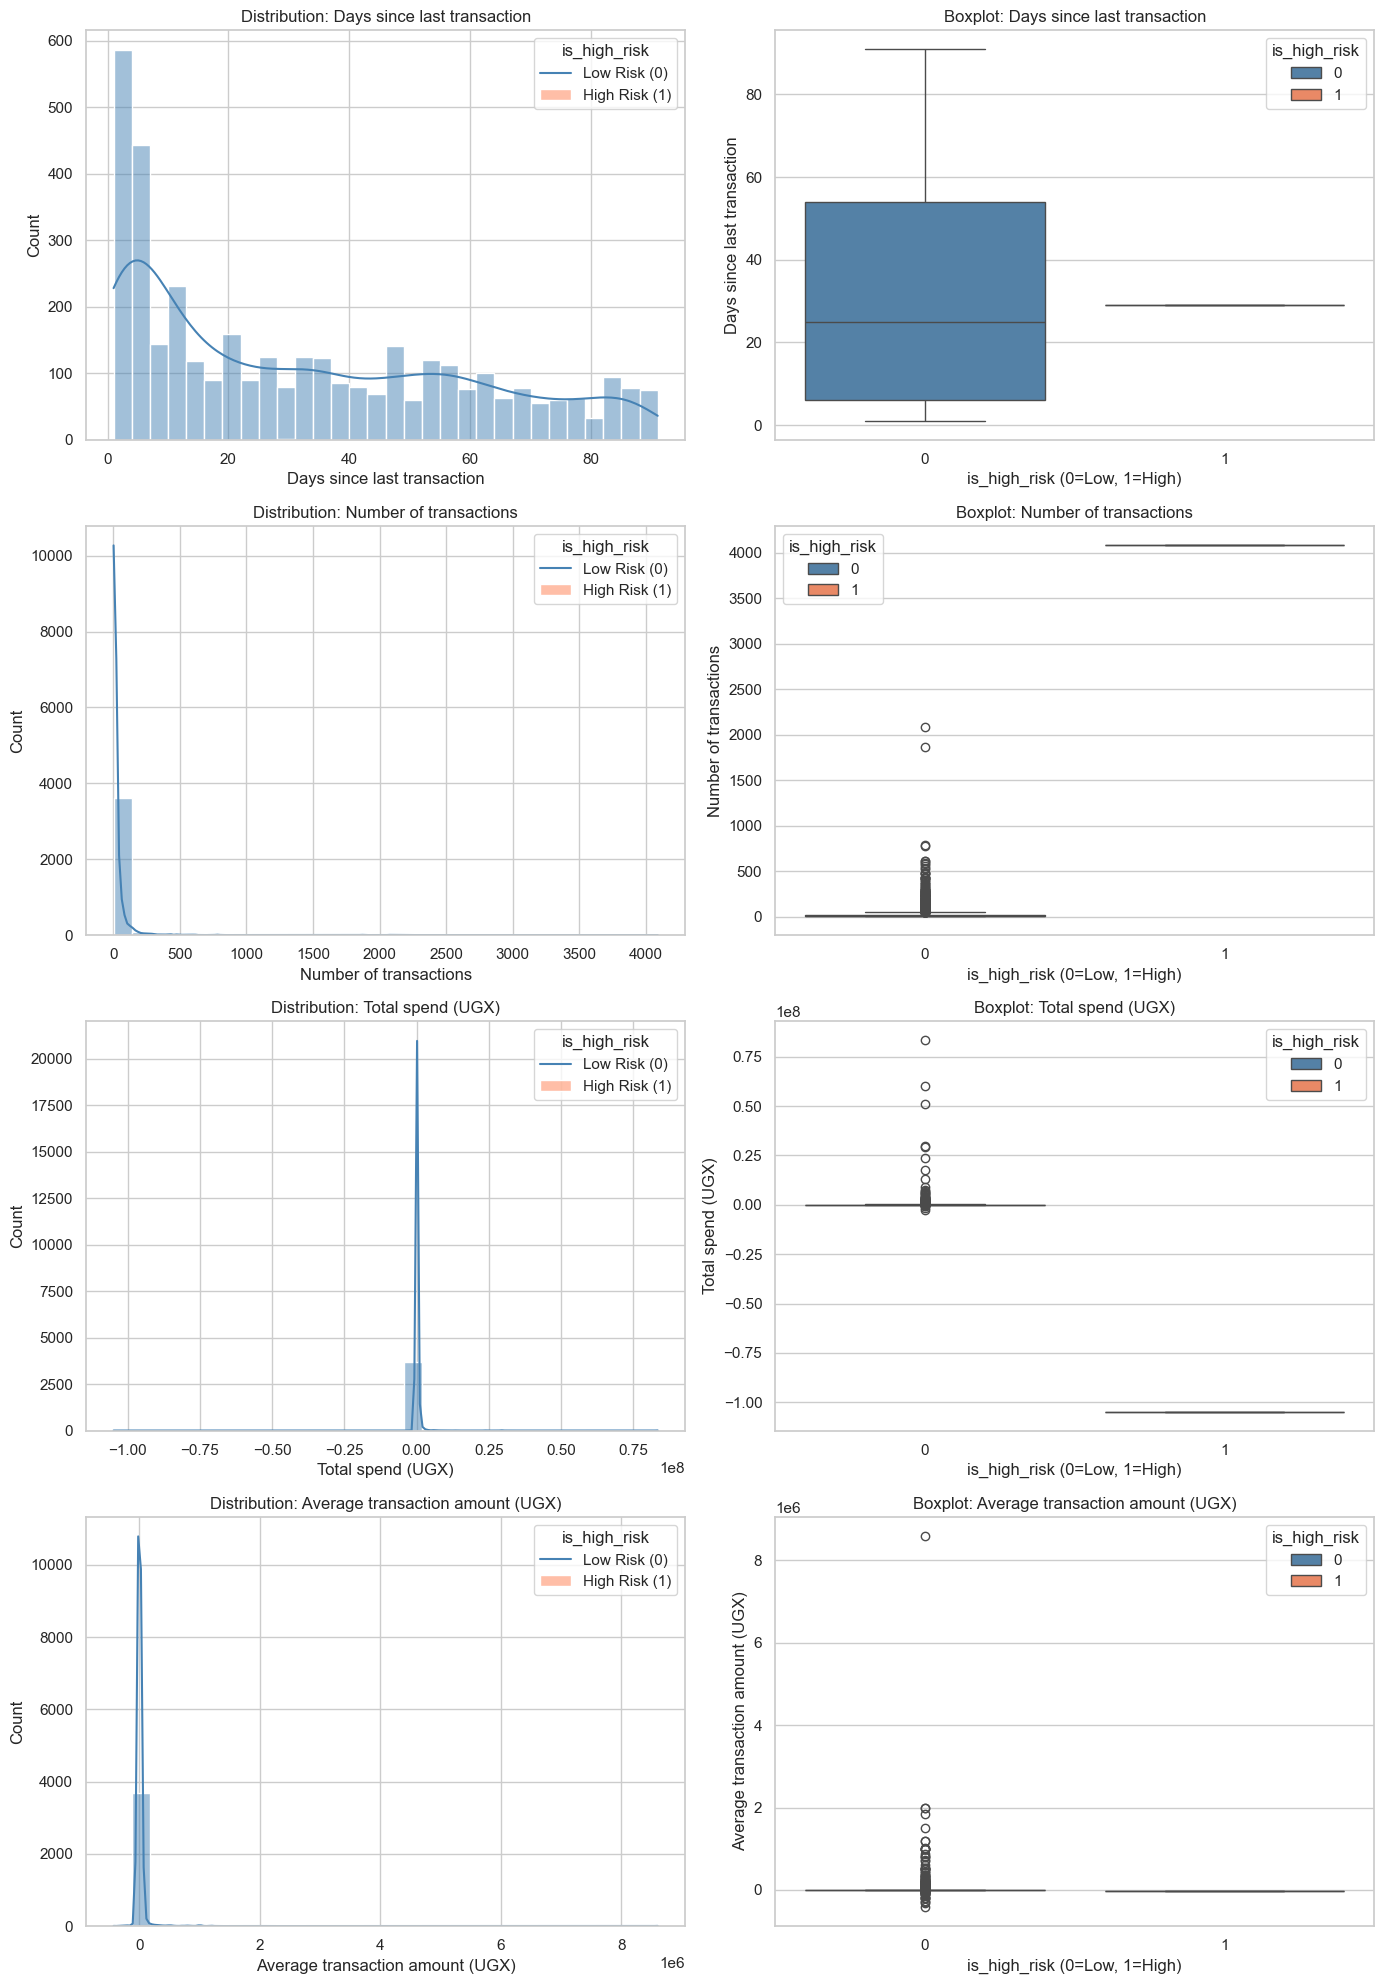

In [29]:
rfm_plot_cols = [
    ("recency_days",      "Days since last transaction"),
    ("transaction_count", "Number of transactions"),
    ("total_amount",      "Total spend (UGX)"),
    ("avg_amount",        "Average transaction amount (UGX)"),
]

fig, axes = plt.subplots(len(rfm_plot_cols), 2, figsize=(14, 5 * len(rfm_plot_cols)))

for i, (col, label) in enumerate(rfm_plot_cols):
    # histogram with hue
    sns.histplot(
        data=rfm, x=col, hue="is_high_risk",
        kde=True, multiple="stack",
        palette={0: "steelblue", 1: "coral"},
        ax=axes[i, 0], bins=30
    )
    axes[i, 0].set_title(f"Distribution: {label}")
    axes[i, 0].set_xlabel(label)
    axes[i, 0].legend(title="is_high_risk", labels=["Low Risk (0)", "High Risk (1)"])

    # boxplot with hue
    sns.boxplot(
        data=rfm, x="is_high_risk", y=col,
        hue="is_high_risk",
        palette={0: "steelblue", 1: "coral"},
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot: {label}")
    axes[i, 1].set_xlabel("is_high_risk (0=Low, 1=High)")
    axes[i, 1].set_ylabel(label)

plt.tight_layout()
plt.show()

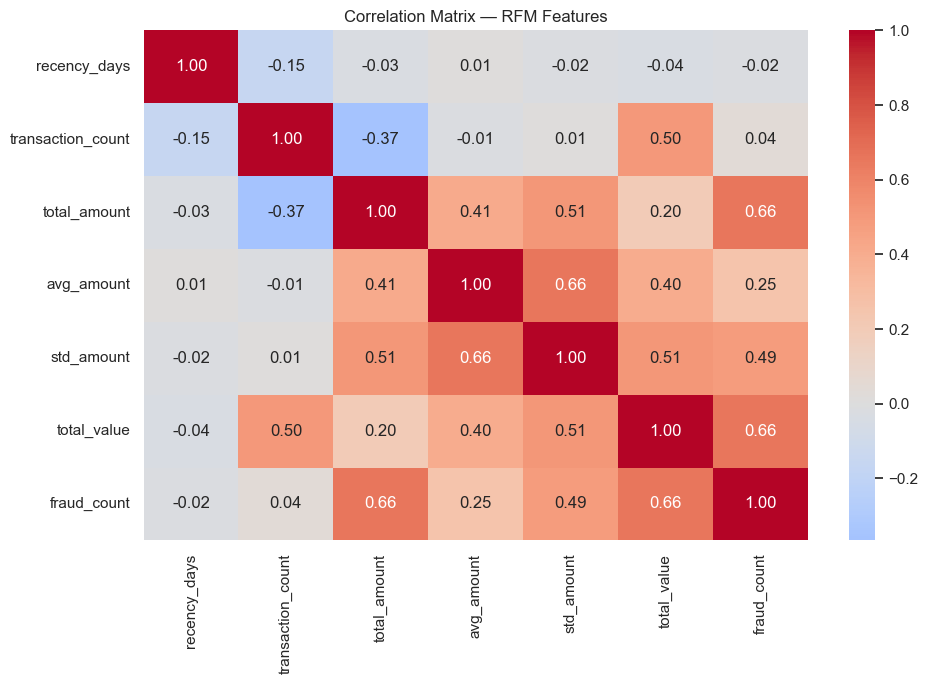

In [30]:
rfm_num = rfm[["recency_days", "transaction_count", "total_amount",
               "avg_amount", "std_amount", "total_value", "fraud_count"]]

plt.figure(figsize=(10, 7))
sns.heatmap(rfm_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — RFM Features")
plt.tight_layout(); plt.show()

## Outlier Detection
Using IQR-based boxplots on RFM numerical features to identify extreme values.

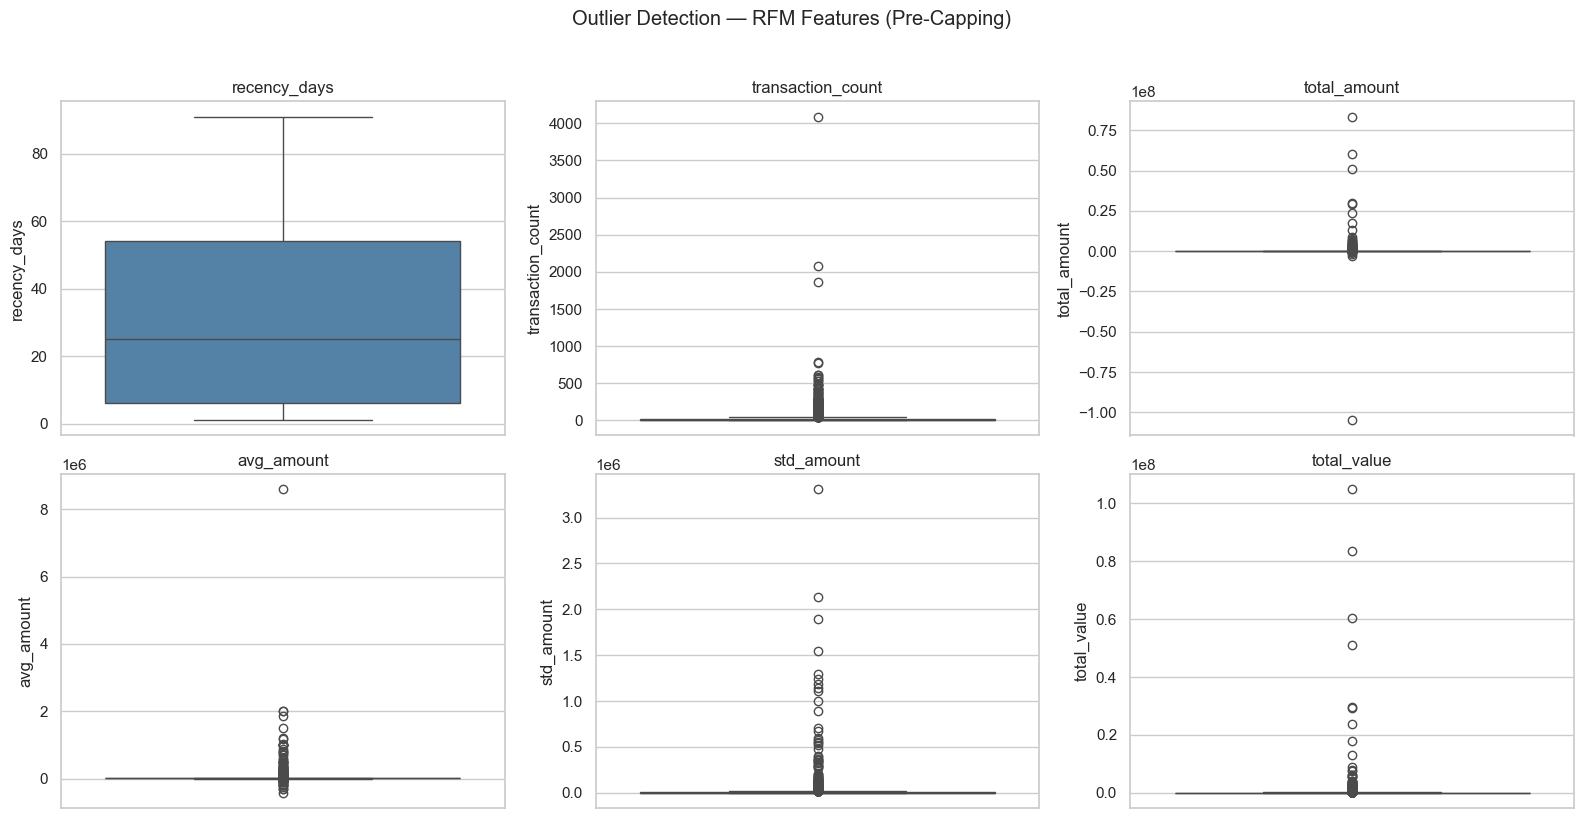

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_check = ["recency_days", "transaction_count", "total_amount",
                 "avg_amount", "std_amount", "total_value"]

for ax, col in zip(axes.flat, cols_to_check):
    sns.boxplot(y=rfm[col], ax=ax, color="steelblue")
    ax.set_title(col)

plt.suptitle("Outlier Detection — RFM Features (Pre-Capping)", y=1.02)
plt.tight_layout(); plt.show()

## Outlier Capping (Winsorization)
IQR-based capping: values below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` are clipped.

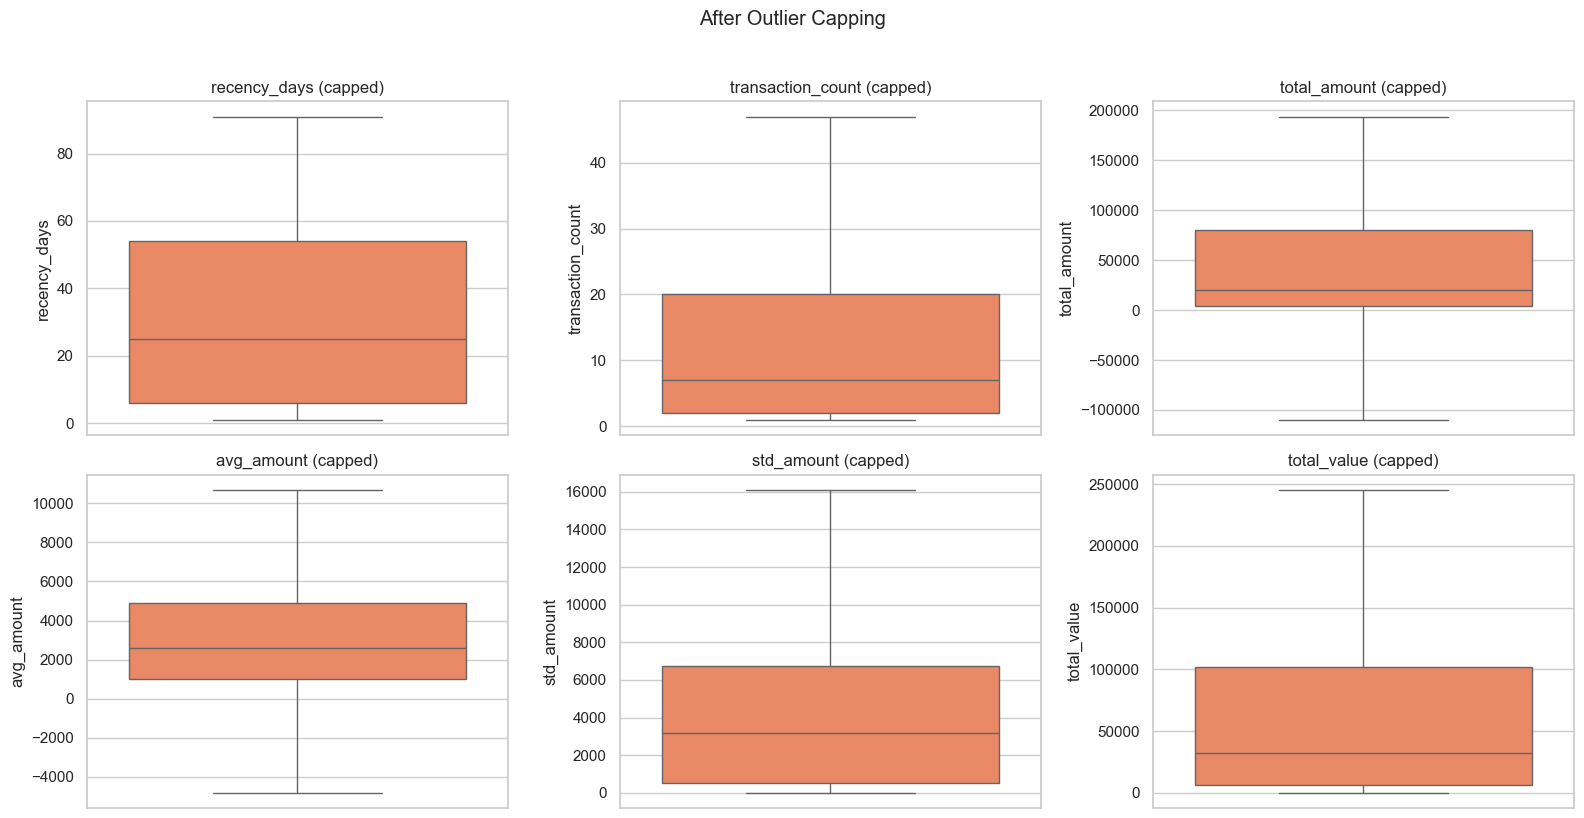

In [32]:
from src.data_processing import OutlierCapper

num_rfm_cols = ["recency_days","transaction_count","total_amount",
                "avg_amount","std_amount","total_value"]

capper = OutlierCapper(cols=num_rfm_cols)
rfm_capped = capper.fit_transform(rfm)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_rfm_cols):
    sns.boxplot(y=rfm_capped[col], ax=ax, color="coral")
    ax.set_title(f"{col} (capped)")

plt.suptitle("After Outlier Capping", y=1.02)
plt.tight_layout(); plt.show()

## Key Insights

1. **Heavy skew in Amount/Value** — a small number of high-value transactions dominate; outlier capping is essential before modeling.
2. **Temporal patterns** — transaction spikes at certain hours/days suggest behavioral features (hour, day-of-week) could be predictive.
3. **Fraud is rare (~<1%)** — severe class imbalance; model evaluation must use AUC-ROC and F1, not accuracy.
4. **`total_amount` and `total_value` are highly correlated** — one may be dropped to reduce redundancy.
5. **`transaction_count` is the strongest RFM signal** — customers with very few transactions are likely disengaged and are the natural high-risk cluster.